In [1]:
import numpy as np
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr

np.random.seed(0)
N = 1000
t = np.linspace(0, 10, N)

ch1 = np.sin(2*np.pi*1.0*t) + 0.2*np.random.randn(N)
# ch2, ch1'in KARESİYLE ilişkili (nonlinear) — Pearson bunu zayıf yakalar
ch2 = ch1**2 + 0.1*np.random.randn(N)

corr, _ = pearsonr(ch1, ch2)
print("Pearson correlation:", round(corr, 3))

Pearson correlation: -0.044


In [2]:
from sklearn.feature_selection import mutual_info_regression

mi_sklearn = mutual_info_regression(ch1.reshape(-1,1), ch2, random_state=0)[0]
print("MI (sklearn, k-NN tabanlı):", round(mi_sklearn, 3))

MI (sklearn, k-NN tabanlı): 1.465


In [3]:
def gaussian_kde_mi(x, y, grid_size=100):
    N = len(x)
    # Scott bandwidth: h = N^(-1/5) * sigma (tek değişken için)
    kde_x = gaussian_kde(x, bw_method='scott')
    kde_y = gaussian_kde(y, bw_method='scott')
    kde_xy = gaussian_kde(np.vstack([x, y]), bw_method='scott')

    x_grid = np.linspace(x.min(), x.max(), grid_size)
    y_grid = np.linspace(y.min(), y.max(), grid_size)
    dx = x_grid[1]-x_grid[0]
    dy = y_grid[1]-y_grid[0]

    px = kde_x(x_grid) * dx
    py = kde_y(y_grid) * dy
    px = px / px.sum()   # normalize (integral ~1 garantisi için)
    py = py / py.sum()

    Hx = -np.sum(px * np.log2(px + 1e-12))
    Hy = -np.sum(py * np.log2(py + 1e-12))

    xx, yy = np.meshgrid(x_grid, y_grid)
    pxy = kde_xy(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape) * dx * dy
    pxy = pxy / pxy.sum()
    Hxy = -np.sum(pxy * np.log2(pxy + 1e-12))

    mi = Hx + Hy - Hxy
    return mi

mi_kde = gaussian_kde_mi(ch1, ch2)
print("MI (Gaussian KDE, makaleye sadık):", round(mi_kde, 3))

MI (Gaussian KDE, makaleye sadık): 0.552


In [4]:
channels_data = {
    "Fp1": ch1,
    "Fp2": ch1 + 0.05*np.random.randn(N),   # Fp1'e çok benzer
    "F3": ch2,                               # Fp1 ile nonlinear ilişkili
    "O1": np.random.randn(N),                # bağımsız gürültü
}
names = list(channels_data.keys())
C = len(names)
MI = np.zeros((C, C))

for i in range(C):
    for j in range(C):
        if i == j:
            MI[i,j] = 0.0   # kendisiyle MI'yi diagonal'de anlamsız bırakıyoruz
        else:
            MI[i,j] = gaussian_kde_mi(channels_data[names[i]], channels_data[names[j]], grid_size=60)

print("MI matrix:\n", np.round(MI, 3))

MI matrix:
 [[ 0.     3.733  0.551 -0.039]
 [ 3.733  0.     0.539 -0.037]
 [ 0.551  0.539  0.    -0.031]
 [-0.039 -0.037 -0.031  0.   ]]


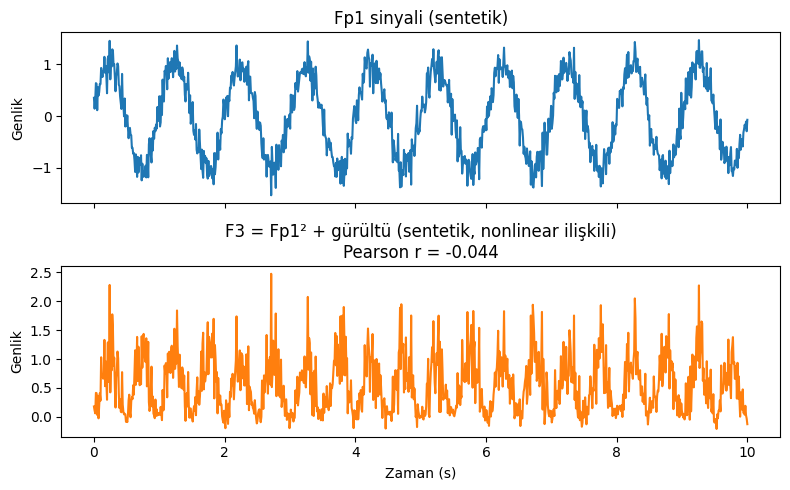

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(t, ch1, color='tab:blue')
axes[0].set_title(f"Fp1 sinyali (sentetik)")
axes[0].set_ylabel("Genlik")

axes[1].plot(t, ch2, color='tab:orange')
axes[1].set_title(f"F3 = Fp1² + gürültü (sentetik, nonlinear ilişkili)\nPearson r = {corr:.3f}")
axes[1].set_ylabel("Genlik")
axes[1].set_xlabel("Zaman (s)")

plt.tight_layout()
plt.show()

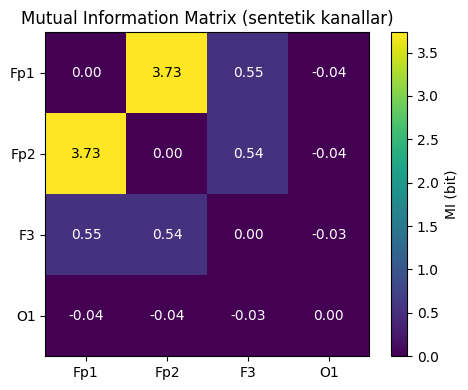

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(MI, cmap='viridis', vmin=0)

ax.set_xticks(range(C))
ax.set_yticks(range(C))
ax.set_xticklabels(names)
ax.set_yticklabels(names)

for i in range(C):
    for j in range(C):
        ax.text(j, i, f"{MI[i,j]:.2f}", ha='center', va='center',
                 color='white' if MI[i,j] < MI.max()/2 else 'black')

ax.set_title("Mutual Information Matrix (sentetik kanallar)")
fig.colorbar(im, ax=ax, label="MI (bit)")
plt.tight_layout()
plt.show()